# Part-2 Computer Vision Problem Formulation and CNN Prototype

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow as tf

# Task 1 - Problem Identification

This dataset represents an **Image Classification** problem.

Reason:
- Each image belongs to one category/class.
- The CNN model predicts the correct class label for each image.
- There are no bounding boxes or segmentation masks, so this is not object detection or segmentation.

In [2]:
# Dataset path

dataset_path = r"C:\Users\Shivangi\Downloads\ai_project_synthetic_datasets-20260516T060838Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision"

images_path = os.path.join(dataset_path, "images")

labels_path = os.path.join(dataset_path, "labels.csv")

## TASK 2 — Dataset Exploration

In [3]:
# Load labels CSV file

df = pd.read_csv(labels_path)

# Display first 5 rows

df.head()

,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


In [4]:
# Display dataset column names

print(df.columns)

Index(['filename', 'class'], dtype='str')


In [7]:
# Combine image folder path with image file names

# `labels.csv` uses 'filename' with relative paths like 'images/normal/..'
# Join with `dataset_path` to get absolute paths
df['image_path'] = df['filename'].apply(lambda x: os.path.join(dataset_path, x))

# Display updated dataframe

df.head()

,filename,class,image_path
0,images/normal/normal_001.png,normal,C:\Users\Shivangi\Downloads\ai_project_synthet...
1,images/normal/normal_002.png,normal,C:\Users\Shivangi\Downloads\ai_project_synthet...
2,images/normal/normal_003.png,normal,C:\Users\Shivangi\Downloads\ai_project_synthet...
3,images/normal/normal_004.png,normal,C:\Users\Shivangi\Downloads\ai_project_synthet...
4,images/normal/normal_005.png,normal,C:\Users\Shivangi\Downloads\ai_project_synthet...


In [12]:
# Count total number of classes

classes = df['class'].unique()

print("Classes:")
print(classes)

print("\nNumber of Classes:", len(classes))

Classes:
<StringArray>
['normal', 'scratch', 'dent', 'stain']
Length: 4, dtype: str

Number of Classes: 4


In [13]:
# Count images in each class

print(df['class'].value_counts())


class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


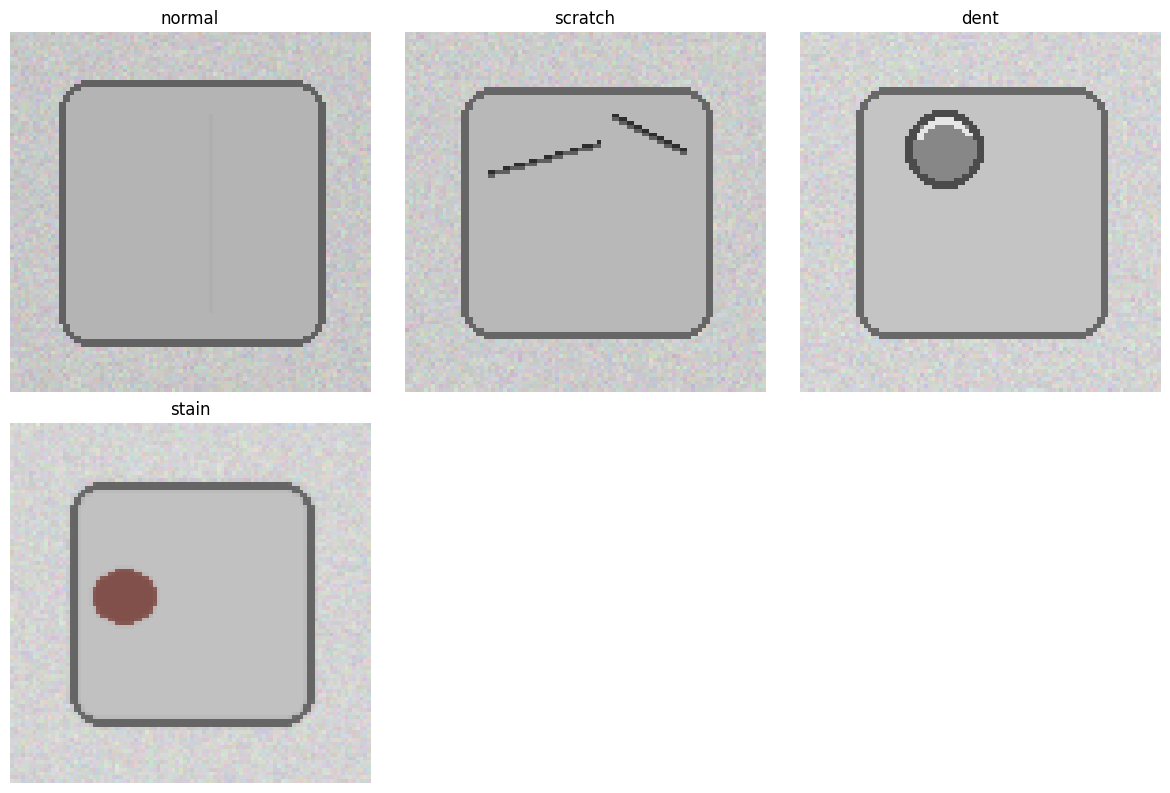

In [15]:
# Display sample images from different classes

plt.figure(figsize=(12,8))

for i, label in enumerate(classes[:6]):

    sample_image = df[df['class'] == label].iloc[0]

    img = plt.imread(sample_image['image_path'])

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(label)

    plt.axis('off')

plt.tight_layout()

plt.show()

In [16]:
# Display image dimensions

sample_image = plt.imread(df.iloc[0]['image_path'])

print("Image Shape:", sample_image.shape)

Image Shape: (96, 96, 3)


# Task 3 - Image Preprocessing

The following preprocessing steps are performed:
- Image resizing
- Pixel normalization
- Train-validation split
- Data augmentation

In [17]:
# Split dataset into training and validation sets

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['class']
)

In [18]:
# Define image size and batch size

img_size = 128
batch_size = 32

# Training image generator with augmentation

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation image generator

val_datagen = ImageDataGenerator(
    rescale=1./255
)

# Training data

train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='class',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

# Validation data

val_data = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='class',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 384 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.


# Task 4 - CNN Model Creation

In [19]:
# Create CNN model

model = Sequential()

# First convolution layer

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

# First pooling layer

model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layer

model.add(Conv2D(64, (3,3), activation='relu'))

# Second pooling layer

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer

model.add(Flatten())

# Dense layer

model.add(Dense(128, activation='relu'))

# Dropout for regularization

model.add(Dropout(0.5))

# Output layer

model.add(Dense(len(classes), activation='softmax'))

c:\Users\Shivangi\Downloads\ai_project_synthetic_datasets-20260516T060838Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Compile CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5 - Model Training and Evaluation

In [21]:
# Train CNN model

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 380ms/step - accuracy: 0.2083 - loss: 2.6183 - val_accuracy: 0.2500 - val_loss: 1.3879
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 324ms/step - accuracy: 0.2526 - loss: 1.3928 - val_accuracy: 0.3333 - val_loss: 1.3845
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 319ms/step - accuracy: 0.2995 - loss: 1.3849 - val_accuracy: 0.5833 - val_loss: 1.3825
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.4219 - loss: 1.3824 - val_accuracy: 0.5729 - val_loss: 1.3730
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - accuracy: 0.4714 - loss: 1.3565 - val_accuracy: 0.6458 - val_loss: 1.2976
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.4740 - loss: 1.2891 - val_accuracy: 0.4792 - val_loss: 1.1850
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 315ms/step - accuracy: 0.5026 - loss: 1.2083 - val_accuracy: 0.6042 - val_loss: 1.0396
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 321ms/step - accuracy: 0.4974 - loss: 1.1596 - val_accuracy: 0.

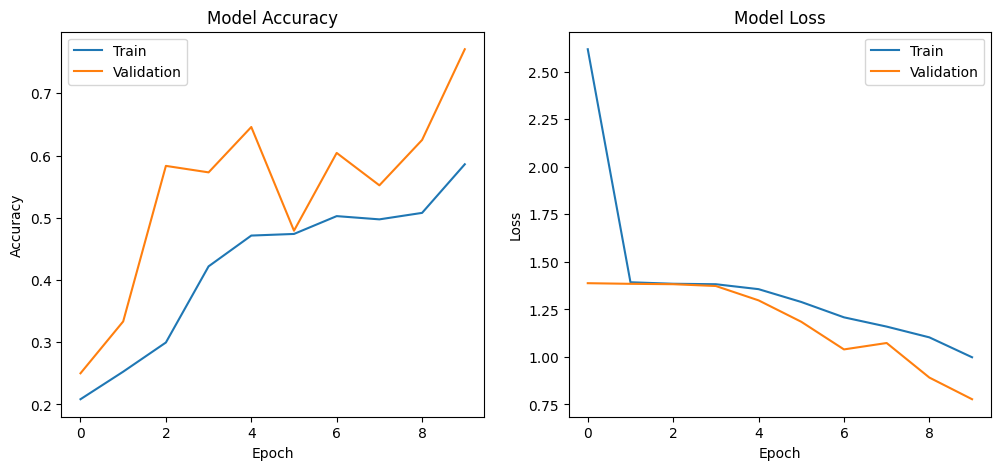

In [22]:
# Plot training and validation accuracy/loss

plt.figure(figsize=(12,5))

# Accuracy graph

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

# Loss graph

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

# Save figure

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


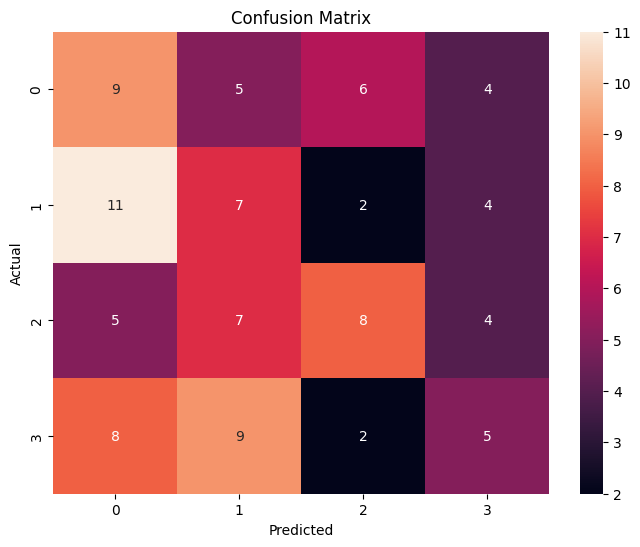

In [23]:
# Generate predictions

Y_pred = model.predict(val_data)

y_pred = np.argmax(Y_pred, axis=1)

# Generate confusion matrix

cm = confusion_matrix(val_data.classes, y_pred)

# Plot confusion matrix

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title("Confusion Matrix")

# Save image

plt.savefig("results/confusion_matrix.png")

plt.show()

In [25]:
# Display classification report

from sklearn.metrics import classification_report


class_names = list(train_data.class_indices.keys())

print(classification_report(
    val_data.classes,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

        dent       0.27      0.38      0.32        24
      normal       0.25      0.29      0.27        24
     scratch       0.44      0.33      0.38        24
       stain       0.29      0.21      0.24        24

    accuracy                           0.30        96
   macro avg       0.32      0.30      0.30        96
weighted avg       0.32      0.30      0.30        96



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


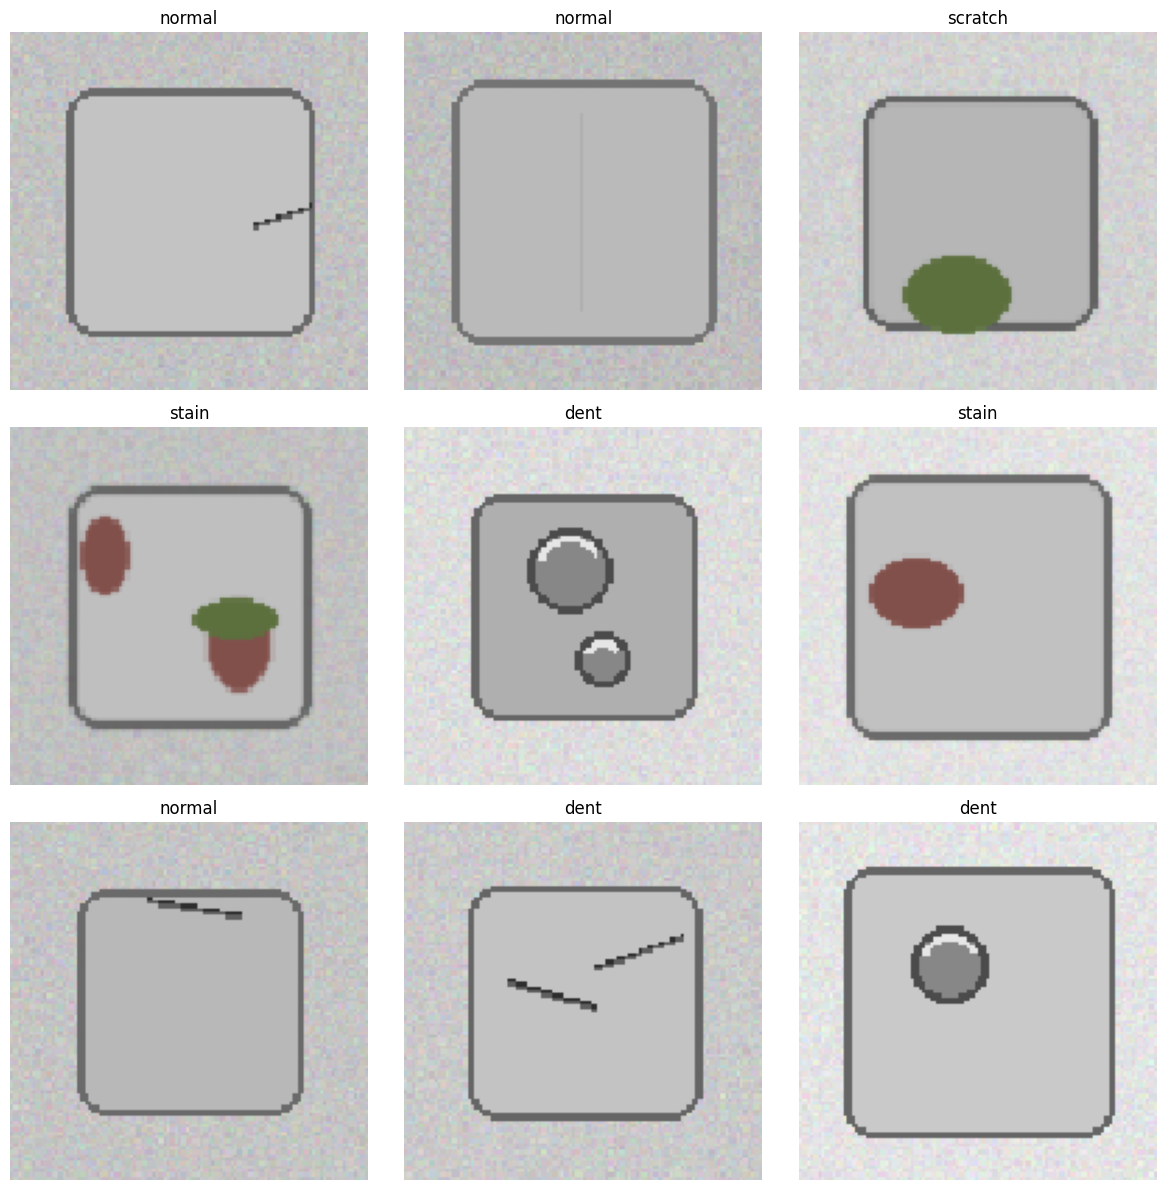

In [26]:
# Display sample predictions

images, labels = next(val_data)

predictions = model.predict(images)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    predicted_class = np.argmax(predictions[i])

    plt.title(class_names[predicted_class])

    plt.axis('off')

plt.tight_layout()

# Save predictions image

plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

# Task 6 - CNN Concept Explanation

## What is Convolution?
Convolution is a process where filters scan the image to detect important patterns such as edges, textures, and shapes.

## Why is Pooling Used?
Pooling reduces image size and computational complexity while keeping important features.

## Why is ReLU Commonly Used?
ReLU helps neural networks learn faster and improves non-linear learning capability.

## Why are CNNs Better for Images?
CNNs automatically learn image features and require fewer parameters than regular feed-forward neural networks.

# Task 7 - Business Use Case Mapping

This type of computer vision solution can be used in healthcare for medical image classification.

Example:
- Detecting diseases from X-ray or MRI images
- Assisting doctors in diagnosis
- Faster medical image analysis

CNN-based systems improve accuracy and reduce manual effort.